Import libraries

In [ ]:
import pandas as pd
import numpy as np
import re

ML

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Load dataset

In [18]:
df = pd.read_csv("/content/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Clean the dataset

In [ ]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

Convert labels into numbers

In [ ]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

Split data into training and testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size=0.2, random_state=42
)

Convert text into numbers using TF-IDF

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Algorithm 1: Naive Bayes

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

Algorithm 2: Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

Algorithm 3: Support Vector Machine

In [ ]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)

Model evaluation

In [ ]:
def check_result(name, y_test, y_pred):
    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
check_result("Naive Bayes", y_test, nb_pred)
check_result("Logistic Regression", y_test, lr_pred)
check_result("SVM", y_test, svm_pred)

Naive Bayes
Accuracy: 0.97847533632287
Precision: 1.0
Recall: 0.84
F1 Score: 0.9130434782608695
Confusion Matrix:
 [[965   0]
 [ 24 126]]
Logistic Regression
Accuracy: 0.9641255605381166
Precision: 0.9741379310344828
Recall: 0.7533333333333333
F1 Score: 0.849624060150376
Confusion Matrix:
 [[962   3]
 [ 37 113]]
SVM
Accuracy: 0.9775784753363229
Precision: 0.9629629629629629
Recall: 0.8666666666666667
F1 Score: 0.9122807017543859
Confusion Matrix:
 [[960   5]
 [ 20 130]]


Model

In [20]:
X_test_tfidf = tfidf.transform(X_test)

# Models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

result_df = pd.DataFrame(results)
result_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966816,1.000000,0.753333,0.859316
1,Logistic Regression,0.952466,0.970874,0.666667,0.790514
2,SVM,0.978475,0.963235,0.873333,0.916084


Graph

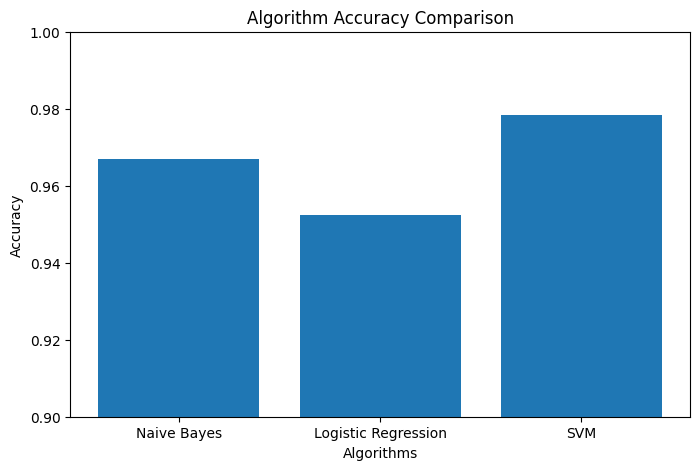

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(result_df["Algorithm"], result_df["Accuracy"])
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Algorithm Accuracy Comparison")
plt.ylim(0.90, 1.00)
plt.show()

Best Algorithm

In [23]:

best_algo = result_df.sort_values(by="Accuracy", ascending=False).iloc[0]
print("Best Algorithm is:", best_algo["Algorithm"])
print("Accuracy:", best_algo["Accuracy"])

Best Algorithm is: SVM
Accuracy: 0.97847533632287


In [ ]:
msg = ["Congratulations! You won a free iPhone. Click now"]
msg_tfidf = tfidf.transform(msg)
prediction = svm.predict(msg_tfidf)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Legitimate Message")

Spam Message


UI

In [ ]:
!pip install gradio scikit-learn pandas numpy

In [24]:
import pandas as pd
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Load Dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels
df['label'] = df['label'].map({'ham':0,'spam':1})

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label'],
    test_size=0.2,
    random_state=42
)

# TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)

# Train Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Prediction Function
def predict_sms(message):

    vector = tfidf.transform([message])

    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "🚨 SPAM MESSAGE"
    else:
        return "✅ LEGITIMATE MESSAGE"

# Gradio UI
ui = gr.Interface(
    fn=predict_sms,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter SMS Here..."
    ),
    outputs="text",
    title="Spam SMS Detection System",
    description="Enter an SMS message to check whether it is Spam or Legitimate."
)

ui.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55ce1ccaa805398b06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
